In [22]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json

pd.set_option('display.max_columns', None)

In [23]:
OPTIONS = json.loads(open('../../info.json', 'r', encoding='utf-8').read())
OPTIONS

{'dynamic_tests': 1, 'static_tests': 1}

# IMPORTANDO DADOS

In [24]:
df_target = pd.read_csv('Target/output/data.csv')
df_target

,time,target_tmp,target_yaw,target_ax,target_roll,target_wx,target_wz,target_az,target_pitch,target_ay,target_wy
0,0.0,59.9,358.186,-0.877783,2.147,0.26370,0.23641,0.372859,-5.197,9.769365,0.09422
1,0.1,60.2,358.185,-0.920825,2.147,-0.10443,-0.33141,0.332681,-5.197,9.757254,-0.00270
2,0.2,59.9,358.185,-0.944125,2.146,0.14189,-0.37010,0.371721,-5.195,9.736817,0.10629
3,0.3,59.9,358.185,-0.971633,2.147,0.20449,-0.62399,0.360561,-5.195,9.791842,0.14559
4,0.4,59.9,358.183,-0.892866,2.149,0.19343,-0.12722,0.350499,-5.196,9.751056,0.19675
...,...,...,...,...,...,...,...,...,...,...,...
3156,315.6,60.2,1.185,-0.862142,2.072,-0.18226,-0.36127,0.343537,-5.040,9.764413,0.20174
3157,315.7,60.3,1.183,-0.894435,2.071,-0.12334,-0.05895,0.364837,-5.040,9.729707,0.16965
3158,315.8,60.3,1.183,-0.812961,2.074,-0.29370,-0.25135,0.321295,-5.038,9.700395,0.29412
3159,315.9,60.2,1.183,-0.863436,2.073,0.26456,-0.12711,0.362464,-5.037,9.722685,0.01304


In [25]:
df_ref = pd.read_csv('Reference/output/data.csv')
df_ref

,time,ref_la_pos_mon_d,ref_yaw,ref_ax,ref_wx,ref_roll,ref_q0,ref_wz,ref_az,ref_pitch,ref_wy,ref_ay,ref_q2,ref_sample_time,ref_q3,ref_q1
0,0.0,-0.04529,-27.226954,0.06865,0.001649,90.298149,0.6851,-0.004888,0.05025,0.269462,-0.027548,-9.788,-0.1652,5000000.0,-0.1676,0.6894
1,0.1,-0.04534,-27.226954,0.06869,0.002540,90.298149,0.6851,-0.001643,0.05016,0.269290,-0.030676,-9.788,-0.1653,105000000.0,-0.1676,0.6894
2,0.2,-0.04538,-27.232684,0.06863,-0.006262,90.298149,0.6851,-0.001564,0.04992,0.269061,-0.029272,-9.788,-0.1653,205000000.0,-0.1676,0.6894
3,0.3,-0.04543,-27.232684,0.06853,-0.005907,90.298149,0.6851,0.003329,0.05004,0.269462,-0.022271,-9.789,-0.1653,305000000.0,-0.1677,0.6894
4,0.4,-0.04547,-27.238414,0.06897,0.001729,90.298149,0.6851,0.002807,0.05005,0.269691,-0.029593,-9.788,-0.1653,405000000.0,-0.1677,0.6894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3156,315.6,0.22300,-28.877073,0.07978,-0.003453,90.298149,0.6829,-0.004904,0.04214,0.100096,-0.025416,-9.788,-0.1761,605000000.0,-0.1765,0.6866
3157,315.7,0.22330,-28.877073,0.07960,-0.006681,90.298149,0.6829,0.002209,0.04216,0.099637,-0.020432,-9.789,-0.1762,705000000.0,-0.1765,0.6866
3158,315.8,0.22360,-28.882802,0.07995,0.000197,90.298149,0.6829,0.001937,0.04192,0.099637,-0.024270,-9.788,-0.1762,805000000.0,-0.1765,0.6866
3159,315.9,0.22390,-28.882802,0.08003,0.019813,90.298149,0.6829,0.013940,0.04169,0.099007,-0.015040,-9.788,-0.1762,905000000.0,-0.1765,0.6866


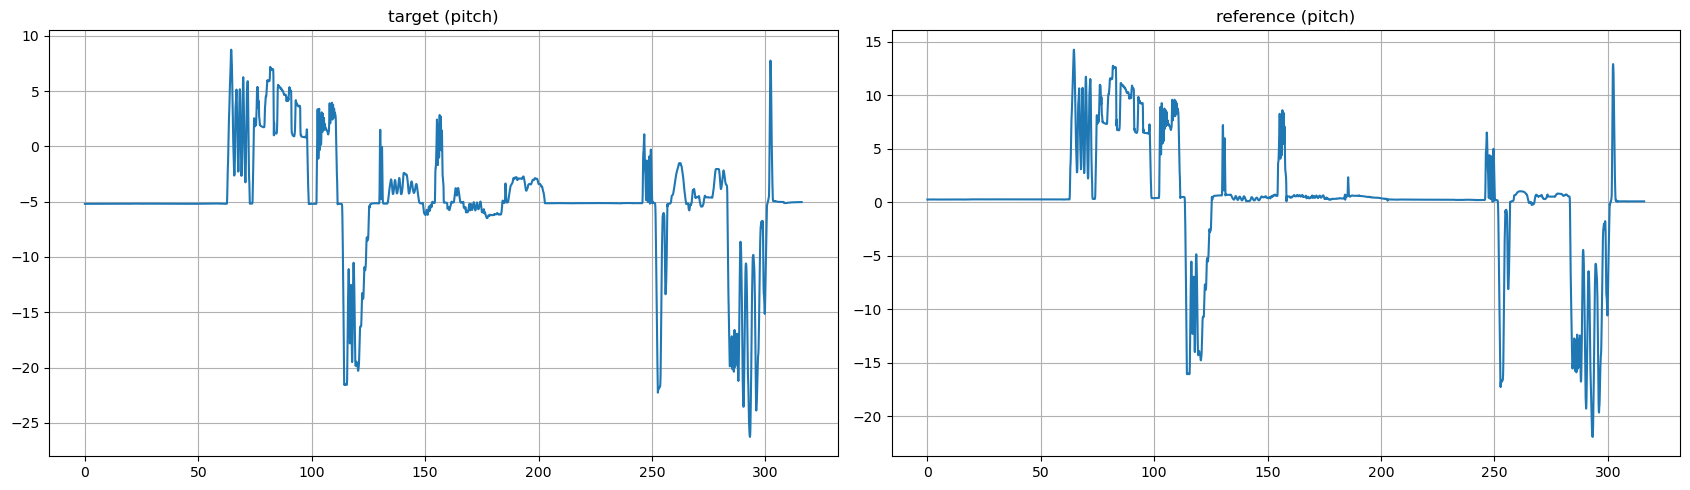

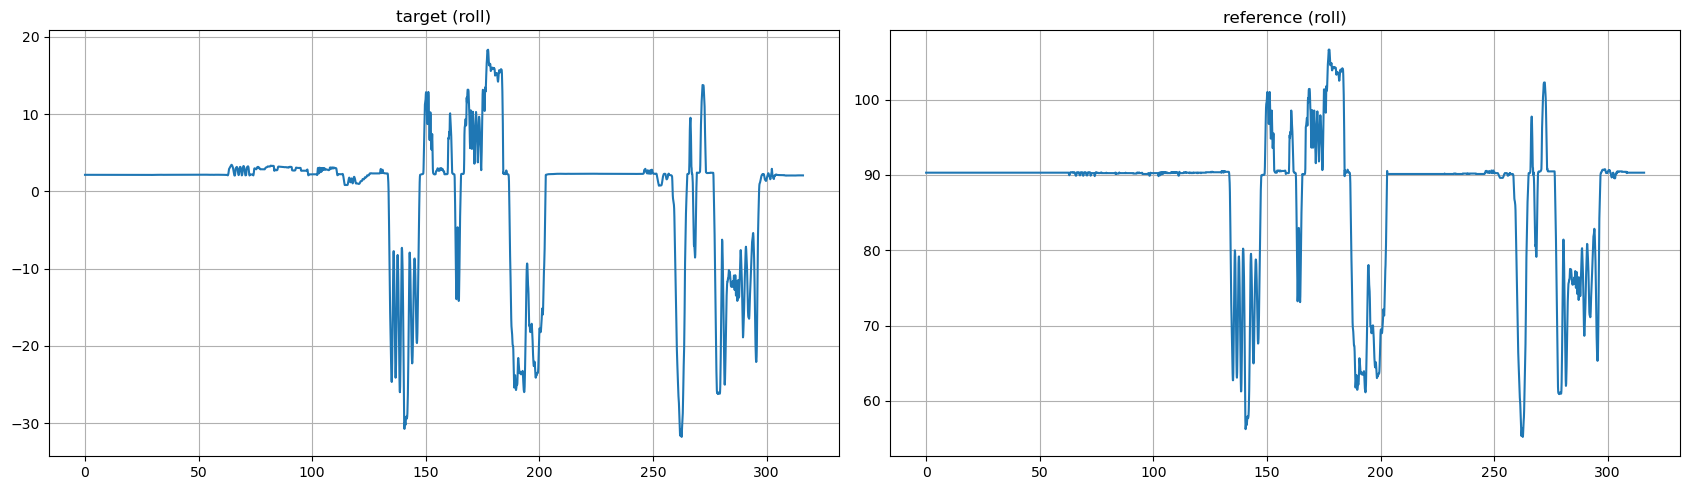

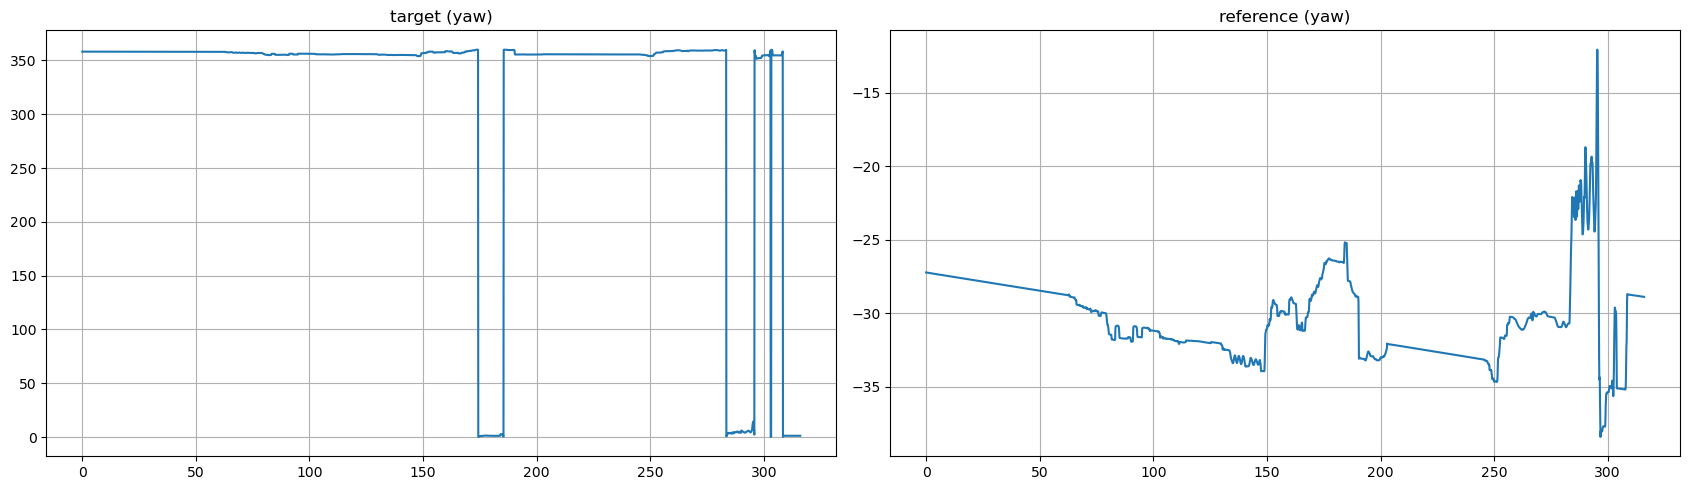

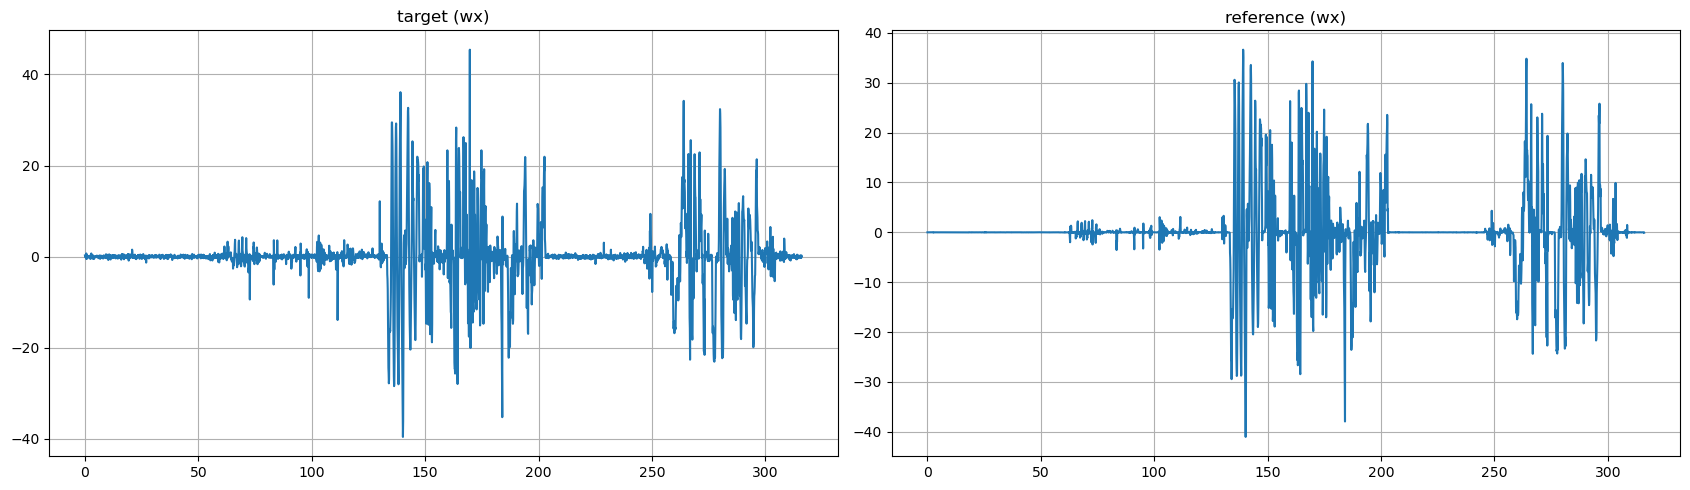

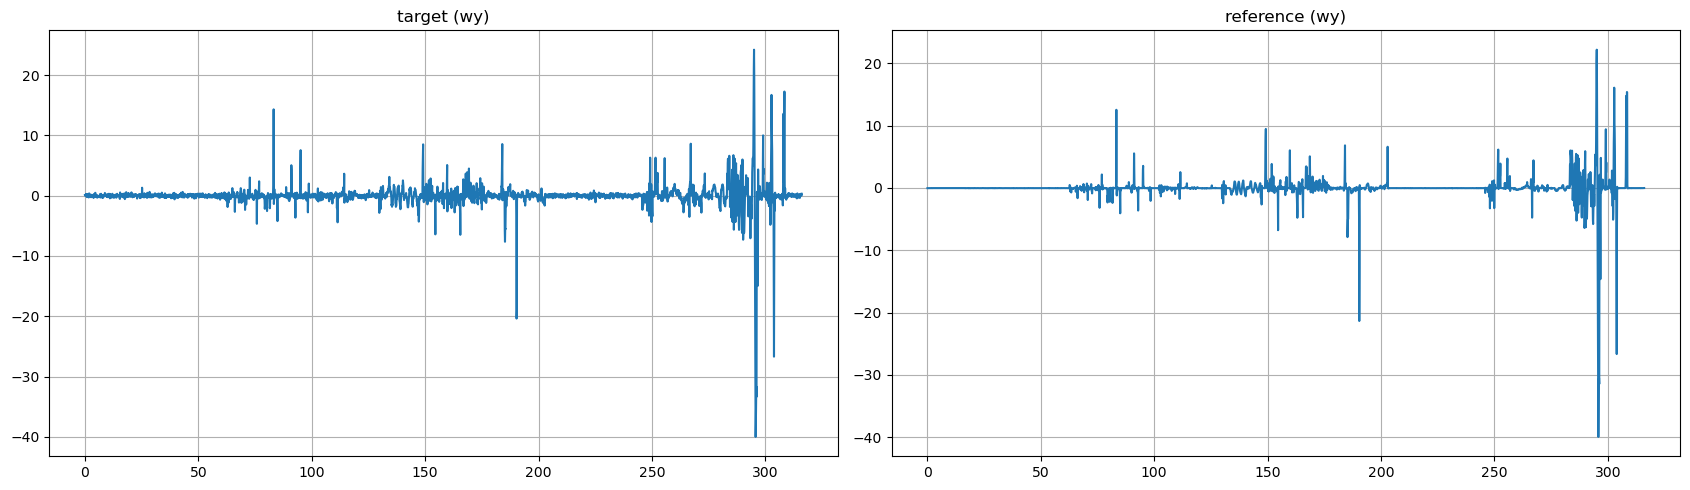

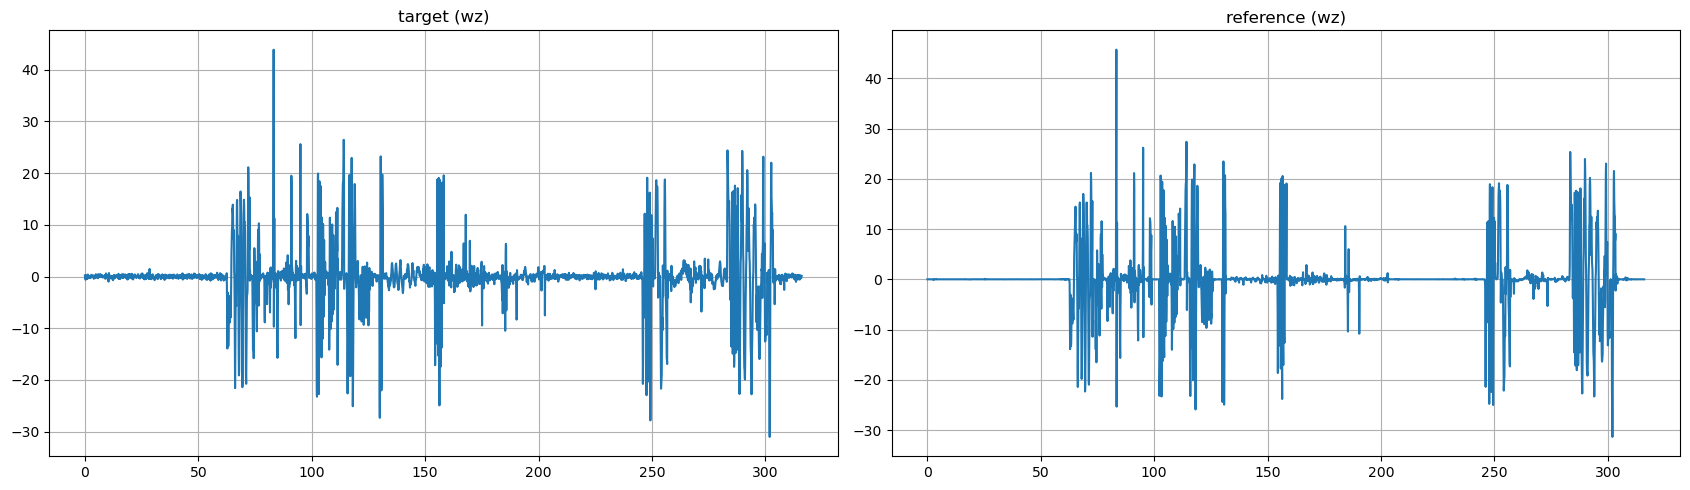

In [26]:
def compareAxis(data, time=None, figsize=None):
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)   
    plt.figure(figsize=figsize if figsize is not None else (6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        time_data = time if time is not None else np.array(range(len(values)))
        
        plt.subplot(numRows, numCols, i+1)
        plt.plot(time_data, values)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()


for var in ['pitch', 'roll', 'yaw', 'wx', 'wy', 'wz']:
    compareAxis({
        f'target ({var})':    df_target[f'target_{var}'], 
        f'reference ({var})': df_ref[f'ref_{var}']
    }, time=df_ref.time, figsize=(17, 5))

In [27]:
df = pd.merge_asof(df_target, df_ref, on='time', direction='nearest')
df

,time,target_tmp,target_yaw,target_ax,target_roll,target_wx,target_wz,target_az,target_pitch,target_ay,target_wy,ref_la_pos_mon_d,ref_yaw,ref_ax,ref_wx,ref_roll,ref_q0,ref_wz,ref_az,ref_pitch,ref_wy,ref_ay,ref_q2,ref_sample_time,ref_q3,ref_q1
0,0.0,59.9,358.186,-0.877783,2.147,0.26370,0.23641,0.372859,-5.197,9.769365,0.09422,-0.04529,-27.226954,0.06865,0.001649,90.298149,0.6851,-0.004888,0.05025,0.269462,-0.027548,-9.788,-0.1652,5000000.0,-0.1676,0.6894
1,0.1,60.2,358.185,-0.920825,2.147,-0.10443,-0.33141,0.332681,-5.197,9.757254,-0.00270,-0.04534,-27.226954,0.06869,0.002540,90.298149,0.6851,-0.001643,0.05016,0.269290,-0.030676,-9.788,-0.1653,105000000.0,-0.1676,0.6894
2,0.2,59.9,358.185,-0.944125,2.146,0.14189,-0.37010,0.371721,-5.195,9.736817,0.10629,-0.04538,-27.232684,0.06863,-0.006262,90.298149,0.6851,-0.001564,0.04992,0.269061,-0.029272,-9.788,-0.1653,205000000.0,-0.1676,0.6894
3,0.3,59.9,358.185,-0.971633,2.147,0.20449,-0.62399,0.360561,-5.195,9.791842,0.14559,-0.04543,-27.232684,0.06853,-0.005907,90.298149,0.6851,0.003329,0.05004,0.269462,-0.022271,-9.789,-0.1653,305000000.0,-0.1677,0.6894
4,0.4,59.9,358.183,-0.892866,2.149,0.19343,-0.12722,0.350499,-5.196,9.751056,0.19675,-0.04547,-27.238414,0.06897,0.001729,90.298149,0.6851,0.002807,0.05005,0.269691,-0.029593,-9.788,-0.1653,405000000.0,-0.1677,0.6894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3156,315.6,60.2,1.185,-0.862142,2.072,-0.18226,-0.36127,0.343537,-5.040,9.764413,0.20174,0.22300,-28.877073,0.07978,-0.003453,90.298149,0.6829,-0.004904,0.04214,0.100096,-0.025416,-9.788,-0.1761,605000000.0,-0.1765,0.6866
3157,315.7,60.3,1.183,-0.894435,2.071,-0.12334,-0.05895,0.364837,-5.040,9.729707,0.16965,0.22330,-28.877073,0.07960,-0.006681,90.298149,0.6829,0.002209,0.04216,0.099637,-0.020432,-9.789,-0.1762,705000000.0,-0.1765,0.6866
3158,315.8,60.3,1.183,-0.812961,2.074,-0.29370,-0.25135,0.321295,-5.038,9.700395,0.29412,0.22360,-28.882802,0.07995,0.000197,90.298149,0.6829,0.001937,0.04192,0.099637,-0.024270,-9.788,-0.1762,805000000.0,-0.1765,0.6866
3159,315.9,60.2,1.183,-0.863436,2.073,0.26456,-0.12711,0.362464,-5.037,9.722685,0.01304,0.22390,-28.882802,0.08003,0.019813,90.298149,0.6829,0.013940,0.04169,0.099007,-0.015040,-9.788,-0.1762,905000000.0,-0.1765,0.6866


In [28]:
df.to_csv('output.csv', index=None)